# Training Dynamics and Regularisation

## Overview

Deep networks overfit easily on small datasets. Regularisation techniques constrain the model during training to improve generalisation. Choosing the right combination is as important as architecture design.

**Regularisation toolbox:**

| Technique | Mechanism | When to use |
|---|---|---|
| L2 weight decay | Penalises large weights | Always: set `weight_decay` in optimiser |
| Dropout | Randomly zeros activations | After dense layers; not after BatchNorm |
| Batch Normalisation | Normalises layer inputs | Before activation in deep networks |
| Early stopping | Stops when val loss stalls | Always: prevents wasted compute and overfit |
| Learning rate schedule | Decays LR over training | All but the smallest problems |
| Data augmentation | Increases effective dataset size | Images / sequences with natural invariances |

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from copy import deepcopy

torch.manual_seed(42)
rng = np.random.default_rng(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

n = 600
elevation   = rng.uniform(50, 400, n).astype(np.float32)
nitrate     = rng.gamma(2, 2, n).astype(np.float32)
phosphorus  = rng.gamma(1.5, 1.5, n).astype(np.float32)
treatment   = rng.choice([0., 1.], n).astype(np.float32)
richness    = (25 - 0.04*elevation - 0.8*nitrate + 2.5*treatment
               + rng.normal(0, 3.5, n)).clip(0).astype(np.float32)
X_np = np.column_stack([elevation, nitrate, phosphorus, treatment])
X_t  = torch.from_numpy(X_np)
y_t  = torch.from_numpy(richness).unsqueeze(1)
split = int(0.8*n)
X_tr, X_va = X_t[:split], X_t[split:]
y_tr, y_va = y_t[:split], y_t[split:]
mu, sd = X_tr.mean(0), X_tr.std(0) + 1e-8
X_tr_n = (X_tr - mu) / sd
X_va_n = (X_va - mu) / sd
train_dl = DataLoader(TensorDataset(X_tr_n.to(device), y_tr.to(device)),
                      batch_size=64, shuffle=True)
print(f"Train={len(X_tr)}, Val={len(X_va)}, device={device}")

Train=480, Val=120, device=cpu


---
## Dropout and Weight Decay

In [2]:
def make_model(hidden=[64,32], dropout=0.0, batchnorm=False):
    layers, in_d = [], 4
    for h in hidden:
        layers.append(nn.Linear(in_d, h))
        if batchnorm:
            layers.append(nn.BatchNorm1d(h))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        in_d = h
    layers.append(nn.Linear(in_d, 1))
    return nn.Sequential(*layers)

def train_model(model, epochs=200, lr=1e-3, wd=0.0, patience=30):
    model = model.to(device)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    crit  = nn.MSELoss()
    best_val, best_state, wait = float('inf'), None, 0
    tr_hist, va_hist = [], []
    for ep in range(epochs):
        model.train()
        losses = []
        for Xb, yb in train_dl:
            opt.zero_grad()
            loss = crit(model(Xb), yb)
            loss.backward(); opt.step()
            losses.append(loss.item())
        model.eval()
        with torch.no_grad():
            vl = crit(model(X_va_n.to(device)), y_va.to(device)).item()
        tr_hist.append(np.mean(losses)); va_hist.append(vl)
        if vl < best_val:
            best_val = vl; best_state = deepcopy(model.state_dict()); wait = 0
        else:
            wait += 1
            if wait >= patience:
                break
    model.load_state_dict(best_state)
    return model, tr_hist, va_hist

configs = {
    'No reg':          make_model(dropout=0.0),
    'Dropout 0.3':     make_model(dropout=0.3),
    'L2 (wd=1e-3)':    make_model(dropout=0.0),
    'Dropout + L2':    make_model(dropout=0.3),
    'BatchNorm':       make_model(dropout=0.0, batchnorm=True),
}
wds = {'No reg':0, 'Dropout 0.3':0, 'L2 (wd=1e-3)':1e-3, 'Dropout + L2':1e-3, 'BatchNorm':0}
results = {}
for name, m in configs.items():
    trained, tr_h, va_h = train_model(m, wd=wds[name])
    results[name] = (tr_h, va_h)
    final_val_rmse = np.sqrt(va_h[np.argmin(va_h)])
    overfit_gap    = tr_h[-1] - va_h[-1]
    print(f"{name:20s}: best val RMSE={final_val_rmse:.3f}, gap={overfit_gap:+.3f}")

No reg              : best val RMSE=3.911, gap=-5.378
Dropout 0.3         : best val RMSE=3.848, gap=+1.229
L2 (wd=1e-3)        : best val RMSE=3.881, gap=-4.687
Dropout + L2        : best val RMSE=3.824, gap=+3.678
BatchNorm           : best val RMSE=4.058, gap=-7.880


---
## Learning Rate Schedules

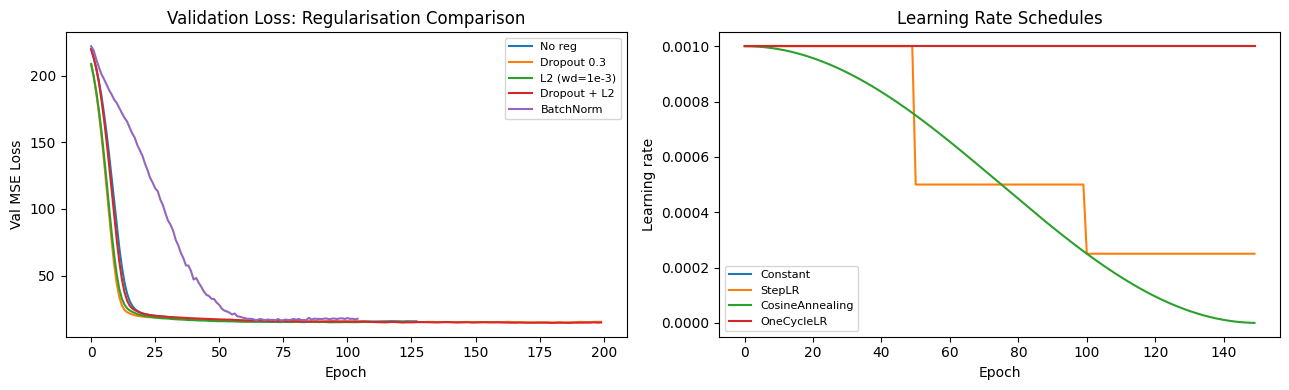

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# Training curves
for name, (tr_h, va_h) in results.items():
    axes[0].plot(va_h, label=name, lw=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val MSE Loss')
axes[0].set_title('Validation Loss: Regularisation Comparison')
axes[0].legend(fontsize=8)

# LR schedule comparison
schedule_configs = {
    'Constant':     (optim.Adam, {}, None),
    'StepLR':       (optim.Adam, {}, lambda opt: optim.lr_scheduler.StepLR(opt, step_size=50, gamma=0.5)),
    'CosineAnnealing': (optim.Adam, {}, lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=150)),
    'OneCycleLR':   (optim.Adam, {}, None),  # special handling
}
for sched_name, (Opt, opt_kw, sched_fn) in schedule_configs.items():
    m = make_model(dropout=0.2).to(device)
    opt_s = Opt(m.parameters(), lr=1e-3, **opt_kw)
    sched = sched_fn(opt_s) if sched_fn else None
    lrs = []
    for ep in range(150):
        lrs.append(opt_s.param_groups[0]['lr'])
        m.train()
        for Xb, yb in train_dl:
            opt_s.zero_grad()
            nn.MSELoss()(m(Xb), yb).backward()
            opt_s.step()
        if sched:
            sched.step()
    axes[1].plot(lrs, label=sched_name, lw=1.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Learning rate')
axes[1].set_title('Learning Rate Schedules')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## Early Stopping

In [4]:
class EarlyStopper:
    def __init__(self, patience=20, min_delta=1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best_loss = float('inf')
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_state = deepcopy(model.state_dict())
            self.counter    = 0
            return False   # continue training
        self.counter += 1
        return self.counter >= self.patience  # stop

model_es = make_model(dropout=0.2).to(device)
opt_es   = optim.Adam(model_es.parameters(), lr=1e-3, weight_decay=1e-4)
crit     = nn.MSELoss()
stopper  = EarlyStopper(patience=25)
tr_h_es, va_h_es = [], []
for ep in range(500):   # large max epoch
    model_es.train()
    for Xb, yb in train_dl:
        opt_es.zero_grad()
        crit(model_es(Xb), yb).backward()
        opt_es.step()
    model_es.eval()
    with torch.no_grad():
        vl = crit(model_es(X_va_n.to(device)), y_va.to(device)).item()
    tr_h_es.append(crit(model_es(X_tr_n.to(device)), y_tr.to(device)).item())
    va_h_es.append(vl)
    if stopper.step(vl, model_es):
        print(f"Early stopping at epoch {ep+1}")
        break
model_es.load_state_dict(stopper.best_state)
print(f"Best val loss: {stopper.best_loss:.4f}, epochs trained: {ep+1}")

Early stopping at epoch 131
Best val loss: 15.2185, epochs trained: 131


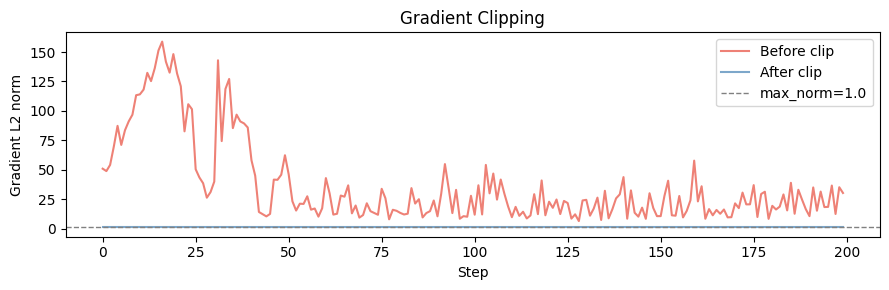

In [5]:
# Gradient clipping: prevents exploding gradients
model_gc = make_model(dropout=0.1).to(device)
opt_gc   = optim.Adam(model_gc.parameters(), lr=5e-3)  # high LR to induce instability
crit     = nn.MSELoss()
grad_norms_clip, grad_norms_raw = [], []
for ep in range(50):
    model_gc.train()
    for Xb, yb in train_dl:
        opt_gc.zero_grad()
        loss = crit(model_gc(Xb), yb)
        loss.backward()
        # Record gradient norm before clipping
        total_norm = 0
        for p in model_gc.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item()**2
        grad_norms_raw.append(total_norm**0.5)
        # Clip gradients
        nn.utils.clip_grad_norm_(model_gc.parameters(), max_norm=1.0)
        total_norm_clipped = 0
        for p in model_gc.parameters():
            if p.grad is not None:
                total_norm_clipped += p.grad.data.norm(2).item()**2
        grad_norms_clip.append(total_norm_clipped**0.5)
        opt_gc.step()
fig, ax = plt.subplots(figsize=(9,3))
ax.plot(grad_norms_raw[:200],  alpha=0.7, label='Before clip', color='#e74c3c')
ax.plot(grad_norms_clip[:200], alpha=0.7, label='After clip',  color='steelblue')
ax.axhline(1.0, color='grey', lw=1, linestyle='--', label='max_norm=1.0')
ax.set_xlabel('Step'); ax.set_ylabel('Gradient L2 norm')
ax.set_title('Gradient Clipping'); ax.legend()
plt.tight_layout(); plt.show()

---

## Common Pitfalls

**1. Using dropout during evaluation without `model.eval()`**  
Dropout randomly zeroes activations during training to prevent co-adaptation of neurons. If `model.eval()` is not called before validation or inference, dropout remains active, producing different predictions on each forward pass and underestimating true model performance.

**2. Applying batch normalisation after dropout**  
Dropout randomly scales the effective batch statistics that BatchNorm uses for normalisation, making training unstable. The correct order is: Linear → BatchNorm → ReLU → Dropout. Never place BatchNorm after Dropout.

**3. Choosing patience for early stopping too small**  
With patience = 5, training stops after 5 epochs of no improvement — which may just be a plateau that resolves with a learning rate decay. Set patience large enough to allow the LR scheduler to react (typically patience ≥ 2× the scheduler's own patience).

**4. Monitoring training loss instead of validation loss for early stopping**  
Training loss decreases monotonically as the model overfits. Early stopping must monitor validation loss — the metric that reflects generalisation. Stopping on training loss prevents learning; stopping on validation loss prevents overfitting.

**5. Not restoring the best model weights after early stopping**  
Early stopping detects when validation loss stopped improving, but the model at that point has already degraded from its best state. Always save the best model checkpoint and restore it after training ends — the final model state is not the best model state.

---
*python_methods_library - Samantha McGarrigle*